# VMEC-JAX First Equilibrium Object

## What you will learn
How a boundary and profile choice becomes an equilibrium file, flux surfaces, rotational transform, and objective inputs.

## Codes used
`vmec_jax` in research mode; xarray/netCDF plus synthetic surface fallback in cached mode.

## Run mode
This notebook uses RUN_MODE = "cached" by default. Allowed values are "tiny", "cached", and "research".

## Expected outputs
HSX-like surface, fetched `wout` inspection when available, and `01_iota_profile.png`.

## What this teaches

The object is the first equilibrium artifact: a boundary/profile choice represented by a VMEC-style wout file and a visible surface.

## What this does not prove

It does not prove that the cached surface is a validated HSX optimization result or that a new VMEC solve converged.

In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src" / "sos2026").exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
print("Project root: repository root detected")

Project root: repository root detected


In [2]:
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    print("Colab detected. Keep RUN_MODE='cached' first; install requirements-colab.txt from the cloned repo if needed.")
else:
    print("Local runtime detected.")

Local runtime detected.


In [3]:
RUN_MODE = "cached"  # allowed: "tiny", "cached", "research"
print(f"RUN_MODE = {RUN_MODE}")

RUN_MODE = cached


In [4]:
import importlib
import json
import math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 160, "axes.spines.top": False, "axes.spines.right": False})

from sos2026.paths import PROJECT_ROOT, DATA_DIR, CACHE_DIR, FIGURE_DIR, MOVIE_DIR, ensure_directories
ensure_directories()
print("Figures:", FIGURE_DIR.relative_to(PROJECT_ROOT))
print("Cached data:", CACHE_DIR.relative_to(PROJECT_ROOT))

Figures: assets/figures
Cached data: data/cached


## 1. Concept: equilibrium is the first state variable

The optimizer does not directly see a beautiful 3D rendering. It sees a parameterized boundary, pressure/current profiles, and an equilibrium solve that returns fields, surfaces, and scalar diagnostics.

In [5]:
from sos2026.vmec_helpers import synthetic_surface, load_iota_profile, find_primary_wout, boundary_mode_scan
from sos2026.plotting import plot_surface_3d, plot_iota_profile, savefig, caption

## 2. Locate the teaching equilibrium

The fetch script downloads a real public HSX `wout` file. If it is absent, this notebook remains usable with synthetic educational data.

In [6]:
wout = find_primary_wout(PROJECT_ROOT, "hsx")
print("HSX wout:", wout.relative_to(PROJECT_ROOT) if wout else "not found; cached fallback will be used")

HSX wout: data/vmec_equilibria/HSX/QHS_vac_ns201_fixed/wout_HSX_QHS_vacuum_ns201.nc


## 3. Inspect the netCDF object when present

A `wout` file is a data product. Before optimizing, inspect dimensions and variable names.

In [7]:
if wout:
    import warnings

    import xarray as xr

    # Some local Python stacks emit an unrelated optional-GPU warning while
    # loading netCDF dependencies. Keep the classroom output focused on the file.
    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            message=".*pynvml package is deprecated.*",
            category=FutureWarning,
        )
        with xr.open_dataset(wout) as ds:
            print("dimensions:", dict(ds.sizes))
            print("first variables:", list(ds.variables)[:18])
else:
    print("No real wout available in this checkout.")

dimensions: {'mn_mode': 200, 'mn_mode_nyq': 200, 'n_tor': 11, 'preset': 21, 'ndfmax': 101, 'radius': 201, 'time': 100}
first variables: ['version_', 'input_extension', 'mgrid_file', 'pcurr_type', 'pmass_type', 'piota_type', 'wb', 'wp', 'gamma', 'rmax_surf', 'rmin_surf', 'zmax_surf', 'nfp', 'ns', 'mpol', 'ntor', 'mnmax', 'mnmax_nyq']


## 4. Plot a surface

This cached surface is pedagogical. It makes the optimizer's geometry object visible without relying on a live VMEC solve.

Caption: the LCFS is the geometry object that stage-1 optimization changes.


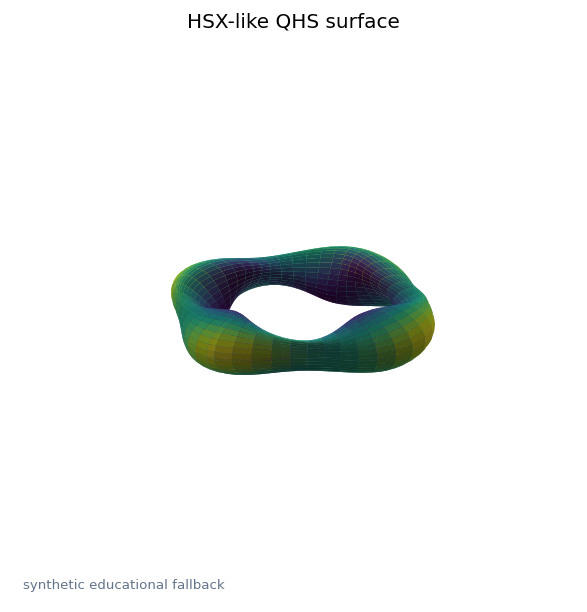

In [8]:
surface = synthetic_surface("hsx")
plot_surface_3d(surface, "HSX-like QHS surface", "01_hsx_surface.png")
print("Caption: the LCFS is the geometry object that stage-1 optimization changes.")

## 5. Plot rotational transform

Rotational transform is not just a label. It controls field-line pitch, resonances, and parts of the objective/constraint set.

iota source: read from wout_HSX_QHS_vacuum_ns201.nc:iotaf
Caption: iota(s) is a profile an optimizer can target, bound, or monitor for resonances.


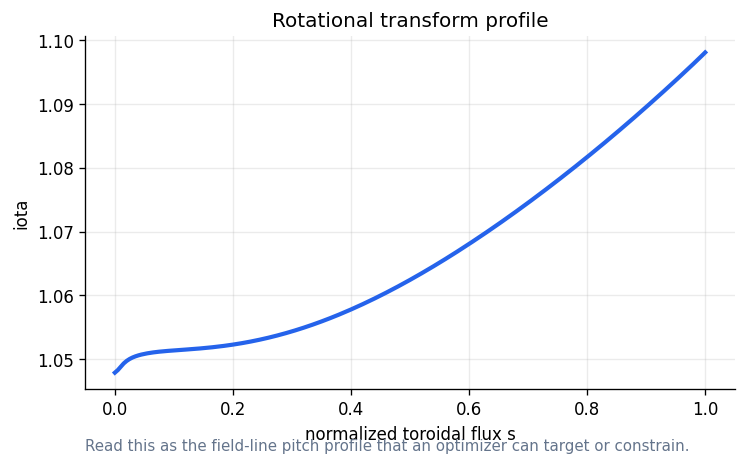

In [9]:
s, iota, source = load_iota_profile(wout)
plot_iota_profile(s, iota)
print("iota source:", source)
print("Caption: iota(s) is a profile an optimizer can target, bound, or monitor for resonances.")

## 6. Turn shape changes into objective changes

A single boundary-mode amplitude can improve one target while damaging another. That is the beginning of multiobjective design.

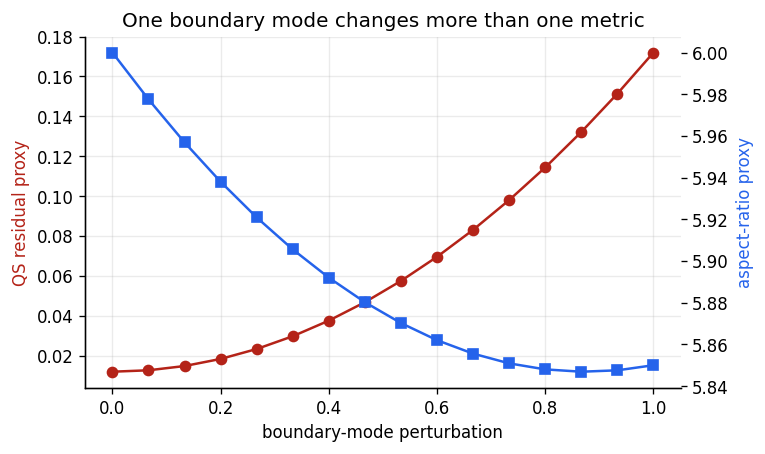

Caption: optimization variables have coupled effects, so scalar objectives need explicit weights and validation.


In [10]:
strength, qs_residual, aspect = boundary_mode_scan()
fig, ax1 = plt.subplots(figsize=(6.4, 3.8))
ax1.plot(strength, qs_residual, marker="o", color="#b42318", label="QS residual")
ax1.set_xlabel("boundary-mode perturbation")
ax1.set_ylabel("QS residual proxy", color="#b42318")
ax2 = ax1.twinx()
ax2.plot(strength, aspect, marker="s", color="#2563eb", label="aspect")
ax2.set_ylabel("aspect-ratio proxy", color="#2563eb")
ax1.set_title("One boundary mode changes more than one metric")
ax1.grid(alpha=0.25)
fig.savefig(FIGURE_DIR / "01_boundary_mode_scan.png", dpi=160, bbox_inches="tight")
plt.show()
print("Caption: optimization variables have coupled effects, so scalar objectives need explicit weights and validation.")

## 7. Research-mode hook

If `vmec_jax` is installed and a tiny input is available, the next step is a fixed-boundary solve. Keep it out of default lecture execution unless it has been timed.

In [11]:
if RUN_MODE == "research":
    import vmec_jax as vj
    print("vmec_jax version:", getattr(vj, "__version__", "unknown"))
    print("Research exercise: run a tiny fixed-boundary input, then compare its wout iota to this cached plot.")
else:
    print("Cached mode: not launching a VMEC solve during class.")

Cached mode: not launching a VMEC solve during class.


## 8. Failure mode

An equilibrium solve can fail, converge to an unexpected state, or be too slow for a live lecture. A robust workflow treats the `wout` file as a checked artifact, not as magic.

In [12]:
checks = pd.DataFrame({
    "check": ["file exists", "netCDF readable", "iota finite", "surface plot available", "runtime acceptable"],
    "cached_mode": [bool(wout), bool(wout), np.all(np.isfinite(iota)), True, True],
})
checks

,check,cached_mode
0,file exists,True
1,netCDF readable,True
2,iota finite,True
3,surface plot available,True
4,runtime acceptable,True


<!-- SOS2026_EXTRA_CLASSROOM_EXAMPLE -->

## Additional classroom example

This final example adds a second view of the same lesson. The goal is to make the GitHub-rendered notebook useful even before a student runs it locally.

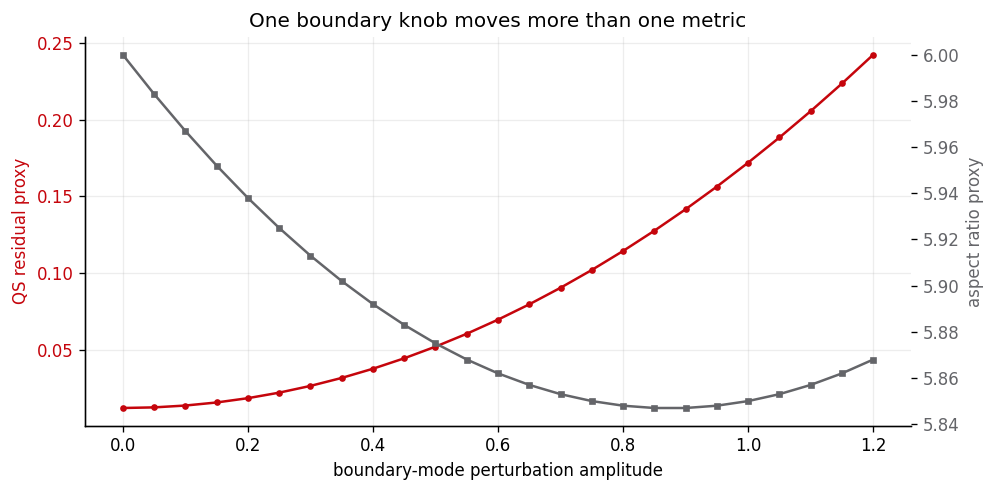

Caption: a single geometry perturbation can improve one metric while moving another, which is why stage-1 optimization is multi-objective.


In [13]:
from sos2026.vmec_helpers import boundary_mode_scan, synthetic_surface
strength, qs_residual, aspect = boundary_mode_scan(np.linspace(0, 1.2, 25))
fig, ax1 = plt.subplots(figsize=(8.4, 4.2))
ax1.plot(strength, qs_residual, color="#c5050c", marker="o", ms=3, label="QS residual proxy")
ax1.set_xlabel("boundary-mode perturbation amplitude")
ax1.set_ylabel("QS residual proxy", color="#c5050c")
ax1.tick_params(axis="y", labelcolor="#c5050c")
ax2 = ax1.twinx()
ax2.plot(strength, aspect, color="#646569", marker="s", ms=3, label="aspect ratio proxy")
ax2.set_ylabel("aspect ratio proxy", color="#646569")
ax2.tick_params(axis="y", labelcolor="#646569")
ax1.set_title("One boundary knob moves more than one metric")
ax1.grid(alpha=0.22)
fig.tight_layout()
plt.show()
print("Caption: a single geometry perturbation can improve one metric while moving another, which is why stage-1 optimization is multi-objective.")

## Output review prompt

Before using this notebook in class, check that the final plot has a clear title, readable axes, and a caption that states what design decision it supports.

## Try this
Increase one synthetic boundary-mode amplitude and watch how the QS residual proxy changes.

## Expected qualitative answer
The configuration becomes more 3D and the proxy residual usually worsens; a real optimizer must balance that against other targets.

## Research extension
Run a tiny `vmec_jax` fixed-boundary input and compare the resulting `wout` variables with the cached HSX file.